# **🌎 Overview**
Preprocess satellite and mask data from training UNet with resnet50 backbone model. Preprocess data, generate training, validation and test dataset.

💡 *This work is based on this [thesis](https://studenttheses.uu.nl/bitstream/handle/20.500.12932/42573/Automatically%20Mapping%20Urban%20Green%20Space%20Using%20Sentinel-2%20Imagery%20and%20Deep%20Learning%20Methods%20in%20Multiple%20Cities%20Worldwide%20A%20Convolutional%20Neural%20Network%20Approach.pdf?sequence=1) and original [code](https://github.com/mar-koz22/Park-NET-identifying-Urban-parks-using-multi-source-spatial-data-and) (Zhao. et al)*   
💡 *Part of this notebook is based on original code by Crista Villatoro—huge thanks for the contribution!* 🙌  

**Code Structure**

## **⚙️ DagsHub and Git Configuration**

In [1]:
# Install dependencies
%pip install -q dagshub[jupyter]

**Git Configuration**

In [2]:
!git config --global user.email {cheng.zhenwk@gmail.com}
!git config --global user.name {chengzwk}

**DagsHub Configuration**

In [3]:
USER_NAME = "chengzwk"

In [4]:
!dagshub login

import dagshub
TOKEN = dagshub.auth.get_token()

                                ❗❗❗ AUTHORIZATION REQUIRED ❗❗❗                                


Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=a3640650-a462-429f-996b-60050ca8a131&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=290961bf6b036e096b326b76b6c0b10204dd64e117704d650d3ad611b0ab4126


⠹ Waiting for authorization
✅ OAuth token added


Accessing as chengzwk

**Clone the dagshub repo**

In [5]:
!git clone https://dagshub.com/Omdena/FrankfurtGermanyChapter_UrbanGreenSpaceMappping.git workspace
%cd workspace

fatal: destination path 'workspace' already exists and is not an empty directory.
/content/workspace


In [6]:
## Make a new directory for training the U-Net model with Resnet50 backbone
%cd TeamBC
%mkdir Unet_Resnet50

/content/workspace/TeamBC
mkdir: cannot create directory ‘Unet_Resnet50’: File exists


**Stream data from DagsHub**

In [7]:
from dagshub.streaming import install_hooks

install_hooks()

Repository "Omdena/FrankfurtGermanyChapter_UrbanGreenSpaceMappping" is now hooked at path 
"/content/workspace/TeamBC/..".
Any calls to Python file access function like open() and listdir() inside of this directory will include results 
from the repository.

## **Debugging and warnings**  
Setup for debugging and suppress warnings.

In [8]:
# Install ipdb for debugging
!pip install ipdb

import ipdb
%pdb on  # Enable automatic debugger calling

Incorrect argument. Use on/1, off/0, or nothing for a toggle.


In [9]:
# Suppress warnings
import logging
logging.getLogger("rasterio").setLevel(logging.ERROR)

## **Data Preparation**

Data preparation can be split into four steps:

1. **Read data**: Import satellite images and corresponding masks, examine their size (128x128 pixels) , and choose the bands want to use.
2. **Dtype conversion**: Convert image array and mask array to the same dtype (np.float64).
3. **Normalization**: Normalize image array to the same scale by band.
4. **Mask conversion**: Convert fractional masks into binary masks.
5. **Balance data**: downsampling the images with high proportion of backgrounds.
6. **Visual inspection**: From the prepared dataset, randomly select and plot 8 images and their corresponding binary mask for visual inpsection.


Our mask files are annotated as 5 classes:
*   12: Impervious surfaces and buildings (class number 2)
*   3: Low vegetation (class number 3, and so on)
*   4: Trees
*   5: Water
*   6: Clutter/Background

When computing proportion of background and urban green space,classes 3 and 4 are counted as urban green space, while other classes are counted as background.

Note that in the case of two classes having the same fractions, this script will convert the binary mask to the first one.

In [10]:
# Install required packages
!pip install pyrsgis
!pip install rasterio
!pip install focal-loss
!pip install segmentation_models

In [11]:
# Import packages
import os
import rasterio
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from osgeo import gdal

In [12]:
def normalize_by_layer(image_array):
    """
    Function to normalize image data to the same max(1) and min(0)
    Since different layers(bands) have different scales, normalization will be done layer by layer
    """
    # Normalize by band
    image_array = image_array.astype(np.float64)  # Convert dtype of image file from int to float64

    for i in range(image_array.shape[2]):
        layer_min = np.min(image_array[:, :, i])
        layer_max = np.max(image_array[:, :, i])

        try:
            image_array[:, :, i] = (image_array[:, :, i] - layer_min) / (layer_max - layer_min)
        except ZeroDivisionError:
            print(f"Band {i} has zero variation (min = max = {layer_min}). Skipping normalization.")
            image_array[:, :, i] = 0  # Set the band to default value 0

    return image_array

In [13]:
'''
def adjust_background_class(mask_data):
    """Adjusts the background class if pixel values do not sum to 1."""
    sum_per_pixel = np.sum(mask_data, axis=0)
    adjustment_needed = (sum_per_pixel < 0.99) | (sum_per_pixel > 1.01)

    if np.any(adjustment_needed):
        print(f"⚠️ Adjusting {np.sum(adjustment_needed)} pixels.")

    corrected_mask = mask_data.copy()
    corrected_mask[-1] += (1 - sum_per_pixel)  # Adjust background class
    return corrected_mask
'''

'\ndef adjust_background_class(mask_data):\n    """Adjusts the background class if pixel values do not sum to 1."""\n    sum_per_pixel = np.sum(mask_data, axis=0)\n    adjustment_needed = (sum_per_pixel < 0.99) | (sum_per_pixel > 1.01)\n\n    if np.any(adjustment_needed):\n        print(f"⚠️ Adjusting {np.sum(adjustment_needed)} pixels.")\n\n    corrected_mask = mask_data.copy()\n    corrected_mask[-1] += (1 - sum_per_pixel)  # Adjust background class\n    return corrected_mask\n'

In [22]:
def read_file(image_dir, mask_dir, subset_size):
    """
    Read satellite image files and corresponding masks as numpy arrays,
    normalize image array to the same scale by band, and convert fractional masks into binary masks.

    Read subset_size image files for training
    """
    image_dataset = []
    mask_dataset = []

    # Print and log progress
    print(f"Reading images and masks from {image_dir} and {mask_dir}")

    # Get list of all image files
    image_files = [f for f in os.listdir(image_dir) if f.endswith('.tif')]
    image_files = image_files[:subset_size]
    total_files = len(image_files)

    # Loop through all iamges files in image_dir
    for i, image_file in enumerate(image_files):

        mask_file = image_file.replace('.tif', '_fractional_mask.tif')
        image_path = os.path.join(image_dir, image_file)
        mask_path = os.path.join(mask_dir, mask_file)

        try:
            # Read image file
            with open(image_path, "rb") as f_img:
                with rasterio.open(f_img) as img:
                    image_array = img.read()
            # image = gdal.Open(image_path)
            # image_array = image.ReadAsArray()
            # print(image_array.shape)

            image_array = np.transpose(image_array, [1, 2, 0])  # move the axis for bands to the third axis
            image_array[np.isnan(image_array)] = 0              # replace nan with 0
            image_array = image_array[:, :, (1, 2, 3)]          # get the bands you want; (1, 2, 3) is RGB bands
            image_array = normalize_by_layer(image_array)       # Normalize the image by band

            # Read mask file
            with open(mask_path, "rb") as f_msk:
                with rasterio.open(f_msk) as msk:
                    mask_array = msk.read()
            # mask = gdal.Open(mask_path)
            # mask_array = mask.ReadAsArray()
            # print(mask_array.shape)

            mask_array = np.transpose(mask_array, [1, 2, 0])               # move the axis for bands to the third axis
            mask_array[np.isnan(mask_array)] = 0                           # replace nan with 0
            classes = np.arange(2, 7)                                      # class numbers: 2, 3, 4, 5, 6
            mask_array = np.argmax(mask_array, axis=2, keepdims=True) + 2  # Convert fractional mask to binary mask

            image_dataset.append(image_array)
            mask_dataset.append(mask_array)

        except Exception as e:
            # logging.error(f'Error processing {image_file}: {e}')
            print(f"Error processing {image_file}: {e}")
            continue  # Skip to next image if an error occurs

    image_dataset = np.array(image_dataset)
    mask_dataset = np.array(mask_dataset)

    mask_dataset = mask_dataset.astype(np.float64)  # Convert dtype of mask file from int to float64

    return image_dataset, mask_dataset


In [15]:
def remove_images(image_dataset, mask_dataset, threshold):
    """
    This function remove images and corresponding masks with high proportion of backgrounds
    Definition of backgrounds:
        - urban green space: classes 3 and 4
        - backgrounds: classes 2, 5, and 6
    Input:
        - image_dataset, mask_dataset: numpy array of satellite images and corresponding masks
        - threshold: if proportion of backgrounds is higher than threshold in the image, the image will be removed
    Output:
        - balanced array without those chips
    """
    # Get the id of images to remove
    id_to_remove = []

    for i in range(len(mask_dataset)):
        mask = mask_dataset[i, :, :, 0]
        tot_pixel = mask.size
        background_pixel = np.count_nonzero(np.isin(mask, [2, 5, 6]))
        if background_pixel > tot_pixel * threshold:
            id_to_remove.append(i)

    # Get the balanced dataset
    image_dataset_balanced = []
    mask_dataset_balanced = []

    for i in range(len(image_dataset)):
        if not(i in id_to_remove):
            image = image_dataset[i]
            mask = mask_dataset[i]
            image_dataset_balanced.append(image)
            mask_dataset_balanced.append(mask)

    image_dataset_balanced = np.array(image_dataset_balanced)
    mask_dataset_balanced = np.array(mask_dataset_balanced)

    return image_dataset_balanced, mask_dataset_balanced

In [16]:
def inspect_dataset(image_dataset, mask_dataset, sample_size, if_binary=False):
    """
    # Randomly select and plot sample_size images and corresponding binary masks for visual inspection
    """
    # Randomly select sample_size files
    samples = random.sample(list(np.arange(len(image_dataset))), min(sample_size, len(image_dataset)))

    sample_images = [image_dataset[i, :, :, :] for i in samples]
    sample_masks = [mask_dataset[i, :, :, :] for i in samples]

    # Define class labels
    class_labels = {
        2: "Class 1&2: impervious",
        3: "Class 3: low veg",
        4: "Class 4: trees",
        5: "Class 5: water",
        6: "Class 6: clutter"}

    class_labels_binary = {
        0: "Class 0: non-vegetation",
        1: "Class 1: vegetation",
    }

    # Define class colors
    class_colors = {
        2: "#808080",  # Gray
        3: "#ADFF2F",  # Light Green
        4: "#006400",  # Dark Green
        5: "#1E90FF",  # Blue
        6: "#8B4513",  # Brown
    }

    class_colors_binary = {
        0: "#808080",  # Gray
        1: "#006400",  # Dark Green
    }

    # Display the randomly selected images and masks
    for i in range(len(sample_images)):
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # Create figure and subplots

        # Plot the satellite image
        axes[0].imshow(sample_images[i][:, :, :3])
        axes[0].set_title("Satellite Image")
        # axes[0].axis("off")

        # Plot the mask with color mapping
        if if_binary:
            cmap = plt.cm.colors.ListedColormap([class_colors_binary[c] for c in sorted(class_colors_binary)])
            colors = class_colors_binary
            labels = class_labels_binary
        else:
            cmap = plt.cm.colors.ListedColormap([class_colors[c] for c in sorted(class_colors)])
            colors = class_colors
            labels = class_labels

        axes[1].imshow(sample_masks[i][:, :, 0], cmap=cmap)
        axes[1].set_title("Mask")
        # axes[1].axis("off")

        # Create a legend and place it outside the plots
        legend_patches = [mpatches.Patch(color=colors[i], label=labels[key]) for i, key in enumerate(labels)]
        fig.legend(handles=legend_patches, loc="center left", bbox_to_anchor=(1.02, 0.5), title="Legend")

        # Adjust layout to make space for the legend
        # plt.tight_layout(rect=[0, 0, 0.85, 1])  # Shrink plot area to fit the legend
        plt.subplots_adjust(right=0.95)


In [17]:
# Convert mask into two classes (veg and non-veg) mask for inital training
def convert_binary_mask(mask_dataset):
    """
    Convert mask into two classes (veg and non-veg) mask for inital training
        - vegetation: classes 3 and 4
        - non-vegetation: classes 2, 5, and 6
    """
    for i in range(len(mask_dataset)):
        mask = mask_dataset[i, :, :, 0]
        mask[np.isin(mask, [3, 4])] = 1
        mask[np.isin(mask, [2, 5, 6])] = 0

    return mask_dataset

In [23]:
# Dataset directory
dataset_dir = 'MULC'

# Get list of all directories under dataset directory
all_dirs = [d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))]

# Get image and mask directories
image_dirs = [d for d in all_dirs if not d.endswith('_masks')]
mask_dirs = [d for d in all_dirs if d.endswith('_masks')]

print("Image Directories:", image_dirs)
print("Mask Directories:", mask_dirs)

# Read image files
subset_size = 100

image_dir = os.path.join(dataset_dir, image_dirs[0])
mask_dir = os.path.join(dataset_dir, image_dirs[0] + '_masks')
image_dataset, mask_dataset = read_file(image_dir, mask_dir, subset_size)

# Covent mask into two classes (veg and non-veg) mask for inital training
mask_dataset = convert_binary_mask(mask_dataset)

# Get the balanced dataset
#image_dataset_balanced, mask_dataset_balanced = remove_images(image_dataset, mask_dataset, 0.86)
#del image_dataset, mask_dataset
#print(image_dataset_balanced.shape, mask_dataset_balanced.shape)

Image Directories: ['SLMO_9R_3', 'SLMO_9R_2', 'VBWVA_8R', 'SLMO_8R_1']
Mask Directories: ['SLMO_9R_3_masks', 'SLMO_9R_2_masks', 'VBWVA_8R_masks', 'SLMO_8R_1_masks']
Reading images and masks from MULC/SLMO_9R_3 and MULC/SLMO_9R_3_masks


In [24]:
# Print satistics of the dataset
print("Image data shape is: ", image_dataset.shape)
print("Mask data shape is: ", mask_dataset.shape)
print("Max pixel value in image is: ", image_dataset.max())
print("Min pixel value in image is: ", image_dataset.min())
print("Labels in the mask are : ", np.unique(mask_dataset))

total_pixels = mask_dataset.size  # Get total number of pixels in the dataset

non_veg_count = np.count_nonzero(mask_dataset == 0)
non_veg_percentage = (non_veg_count / total_pixels) * 100
print(f"Number of non-veg pixels: {non_veg_count} ({non_veg_percentage:.2f}%)")

veg_count = np.count_nonzero(mask_dataset == 1)
veg_percentage = (veg_count / total_pixels) * 100
print(f"Number of vegetation pixels: {veg_count} ({veg_percentage:.2f}%)")


Image data shape is:  (100, 128, 128, 3)
Mask data shape is:  (100, 128, 128, 1)
Max pixel value in image is:  1.0
Min pixel value in image is:  0.0
Labels in the mask are :  [0. 1.]
Number of non-veg pixels: 765835 (46.74%)
Number of vegetation pixels: 872565 (53.26%)


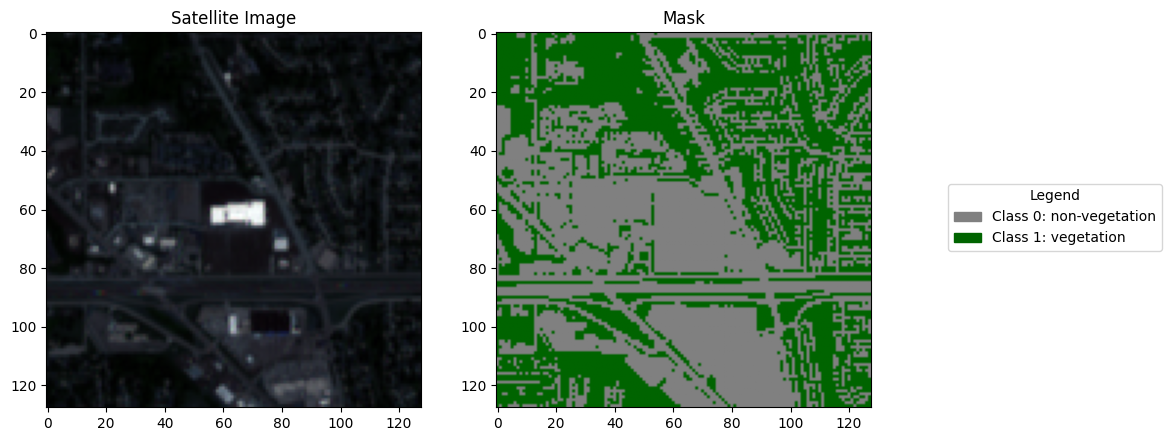

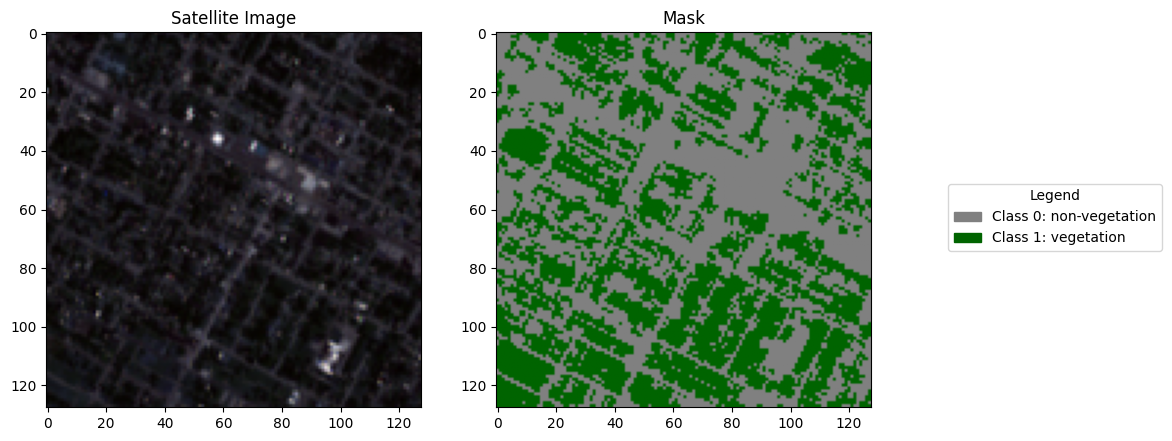

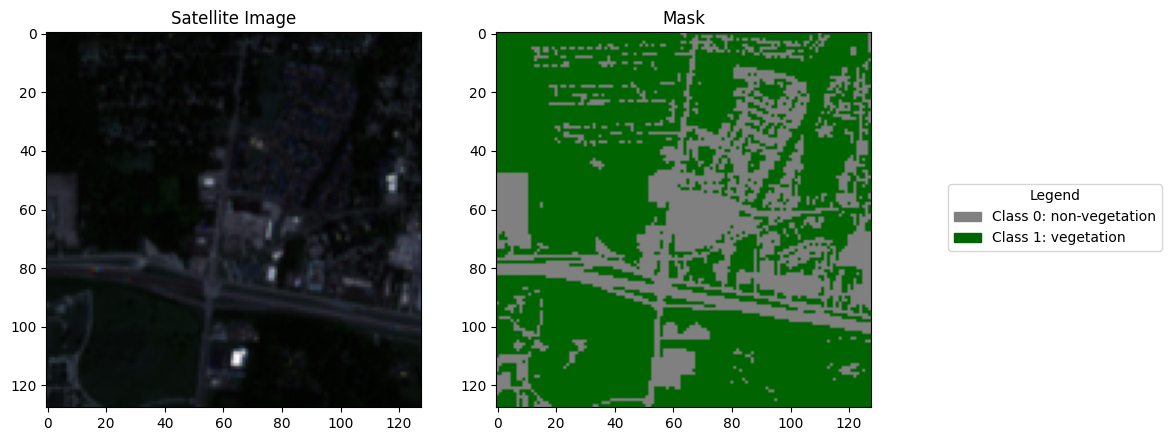

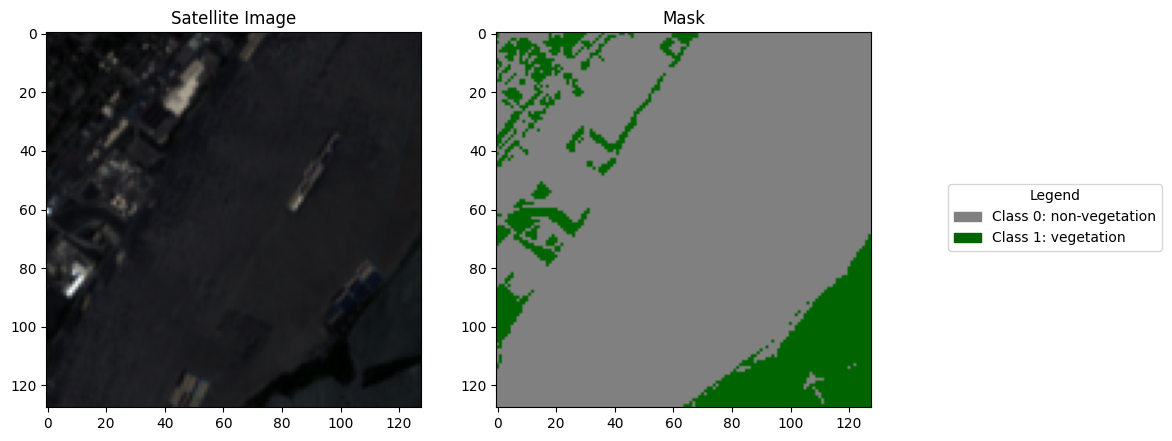

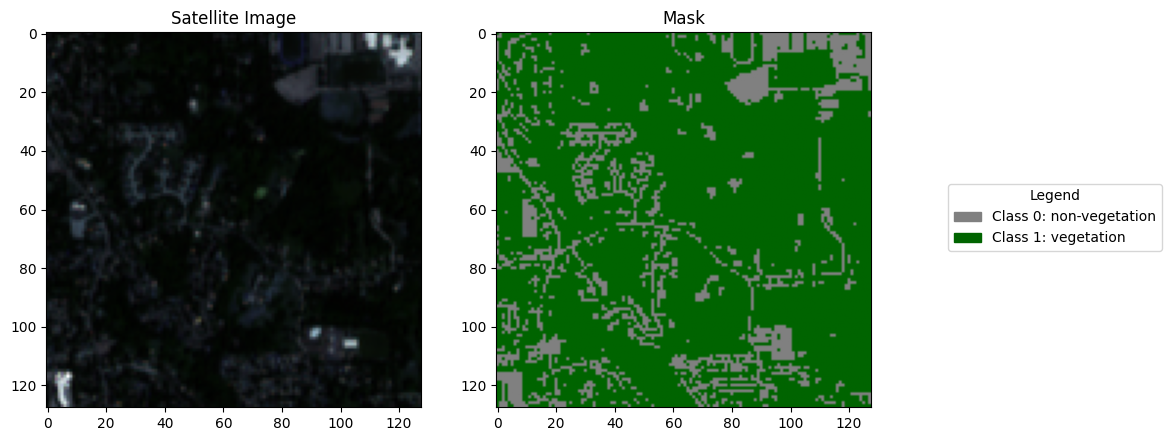

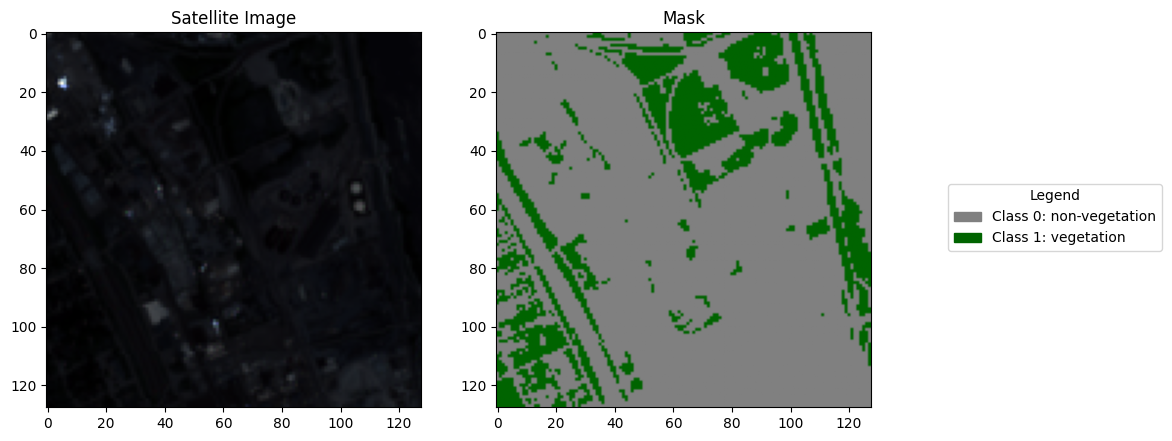

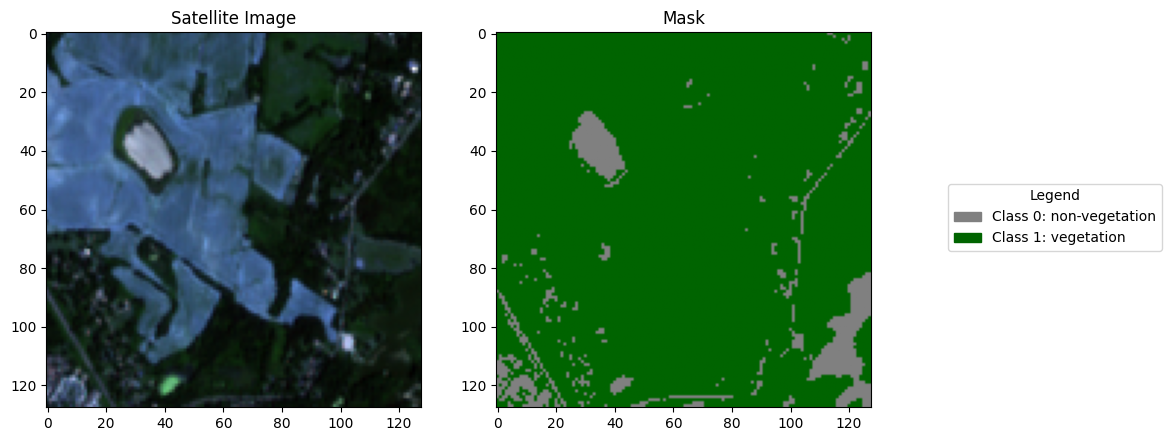

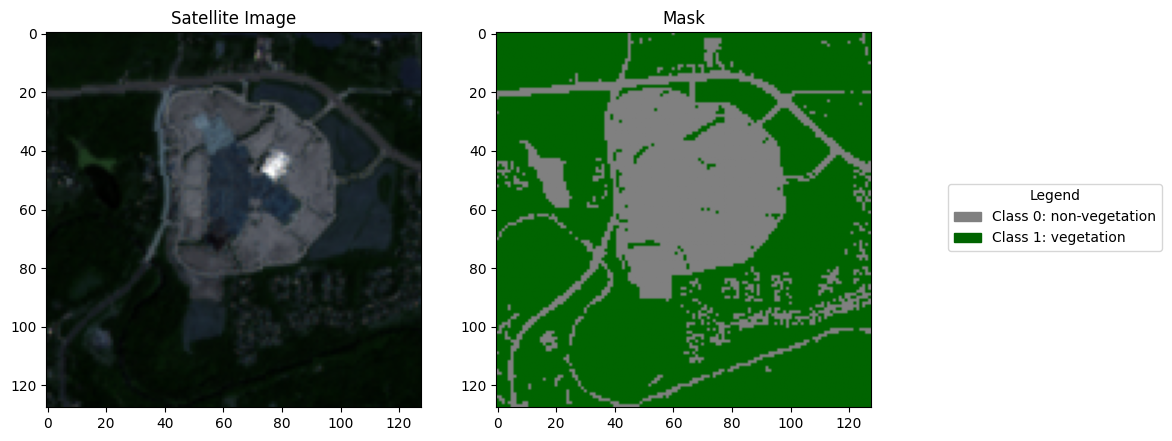

In [25]:
# Visually inspect the dataset
inspect_dataset(image_dataset, mask_dataset, 8, if_binary=True)

In [26]:
# Print satistics of the dataset for multi-class case
'''
for i in range(2, 7):
    count = np.count_nonzero(mask_dataset == i)
    percentage = (count / total_pixels) * 100
    print(f"Number of cells with value {i}: {count} ({percentage:.2f}%)")

background_count = np.count_nonzero(np.isin(mask_dataset, [2, 5, 6]))
background_percentage = (background_count / total_pixels) * 100
print(f"Number of background pixels: {background_count} ({background_percentage:.2f}%)")

low_veg_count = np.count_nonzero(mask_dataset == 3)
low_veg_percentage = (low_veg_count / total_pixels) * 100
print(f"Number of low vegetation pixels: {low_veg_count} ({low_veg_percentage:.2f}%)")

tree_count = np.count_nonzero(mask_dataset == 4)
tree_percentage = (tree_count / total_pixels) * 100
print(f"Number of tree pixels: {tree_count} ({tree_percentage:.2f}%)")
'''

'\nfor i in range(2, 7):\n    count = np.count_nonzero(mask_dataset == i)\n    percentage = (count / total_pixels) * 100\n    print(f"Number of cells with value {i}: {count} ({percentage:.2f}%)")\n\nbackground_count = np.count_nonzero(np.isin(mask_dataset, [2, 5, 6]))\nbackground_percentage = (background_count / total_pixels) * 100\nprint(f"Number of background pixels: {background_count} ({background_percentage:.2f}%)")\n\nlow_veg_count = np.count_nonzero(mask_dataset == 3)\nlow_veg_percentage = (low_veg_count / total_pixels) * 100\nprint(f"Number of low vegetation pixels: {low_veg_count} ({low_veg_percentage:.2f}%)")\n\ntree_count = np.count_nonzero(mask_dataset == 4)\ntree_percentage = (tree_count / total_pixels) * 100\nprint(f"Number of tree pixels: {tree_count} ({tree_percentage:.2f}%)")\n'

## **Build training and test set**

**Split and preprocess to fit model architecture**

In [27]:
# Train-validation-test split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(image_dataset, mask_dataset, test_size = 0.15, random_state = 42)

del image_dataset, mask_dataset
print(X_train.shape, X_val.shape)
print(y_train.shape, y_val.shape)

(85, 128, 128, 3) (15, 128, 128, 3)
(85, 128, 128, 1) (15, 128, 128, 1)


In [28]:
# preprocess input to fit model architecture
%env SM_FRAMEWORK=tf.keras
import segmentation_models as sm
import keras
import tensorflow
from keras.layers import Input, Conv2D
from keras.models import Model

BACKBONE = 'resnet50'
preprocess_input = sm.get_preprocessing(BACKBONE)  # get the preprocessing function

X_train = preprocess_input(X_train)
X_val = preprocess_input(X_val)
print(X_train.shape, X_val.shape)

env: SM_FRAMEWORK=tf.keras
Segmentation Models: using `tf.keras` framework.
(85, 128, 128, 3) (15, 128, 128, 3)


In [29]:
# turn mask_dataset into categorical (one-hot encoding to fit the model architecture)
from tensorflow.keras.utils import to_categorical

# Adjust class values
# y_train_adjusted = y_train - 2  # Shift class values from 2-6 to 0-4
# y_val_adjusted = y_val - 2

# y_train
train_masks_cat = to_categorical(y_train, num_classes=2)
y_train_cat = train_masks_cat.reshape((y_train.shape[0], y_train.shape[1], y_train.shape[2], -1))

# y_val
val_masks_cat = to_categorical(y_val, num_classes=2)
y_val_cat = val_masks_cat.reshape((y_val.shape[0], y_val.shape[1], y_val.shape[2], -1))

print(y_train_cat.shape, y_val_cat.shape)


(85, 128, 128, 2) (15, 128, 128, 2)


## **Save training and test set and track data changes**

In [ ]:
# save data to file
# save X_train, y_train_cat, X_val, y_val_cat to file

In [ ]:
# track data changes with dvc in dagshub
# import dagshub

#dagshub.upload_files(local_path="data/", remote_path="data/",
#            commit_message="Added Raw Data",versioning="dvc",
#               repo=f"{USER_NAME}/{REPO_NAME}")

# Pull the new commit created by DagsHub with the DVC pointer file
#!git pull -r origin

## **📀 Save the notebook to DagsHub**

In [ ]:
from dagshub.notebook import save_notebook

repo = "Omdena/FrankfurtGermanyChapter_UrbanGreenSpaceMappping"
notebook_path = "TeamBC/Unet_Resnet50/data-preprocessing.ipynb"
commit_message = "Create Unet_Resnet50 directory and add data preprocessing notebook"

save_notebook(repo=repo,
              branch = "main",
              path=notebook_path,
              commit_message=commit_message,
              versioning="git")

Uploading files (1) to "Omdena/FrankfurtGermanyChapter_UrbanGreenSpaceMappping"...

Upload finished successfully!

In [ ]:
from dagshub.notebook import save_notebook

USER_NAME = "chengzwk"
REPO_NAME = "omdena-frankfurt-ugs-unet"

repo = f"{USER_NAME}/{REPO_NAME}"
notebook_path = "Unet_Resnet50/data-preprocessing.ipynb"

# Add the commit message
commit_message = "Complete data preprocessing code. Need to add new data saving and tracking part."

save_notebook(repo=repo,
              branch = "main",
              path=notebook_path,
              commit_message=commit_message,
              versioning="git")